In [2]:
import os
import re
import math
import random
import unicodedata
import subprocess
import sys
from pathlib import Path

# Arabic display helpers
def _ensure_pkg(pkg):
    try:
        __import__(pkg.replace("-", "_"))
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

for _pkg in ["arabic-reshaper", "python-bidi", "seaborn"]:
    _ensure_pkg(_pkg)

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import arabic_reshaper
from bidi.algorithm import get_display

from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

QWEN_MODEL = "Qwen/Qwen2.5-1.5B-Instruct"
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

CANDIDATE_DIRS = [
    Path("."),
    Path("/content"),
    Path("/mnt/data"),
]

def find_existing_file(name: str) -> Path:
    for d in CANDIDATE_DIRS:
        p = d / name
        if p.exists():
            return p
    raise FileNotFoundError(f"Could not find {name} in: {[str(d) for d in CANDIDATE_DIRS]}")

SCORED_CSV = find_existing_file("jawaher_qwen_scored.csv")
MASK_CSV = find_existing_file("jawaher_qwen_masking.csv")
IMP_CSV = find_existing_file("jawaher_qwen_masking_importance.csv")

print("Using files:")
print("  scored :", SCORED_CSV)
print("  masking:", MASK_CSV)
print("  imp    :", IMP_CSV)

def shape_ar(text):
    text = "" if pd.isna(text) else str(text)
    try:
        return get_display(arabic_reshaper.reshape(text))
    except Exception:
        return text

plt.rcParams["font.family"] = "DejaVu Sans"
sns.set_style("whitegrid")


Using files:
  scored : jawaher_qwen_scored.csv
  masking: jawaher_qwen_masking.csv
  imp    : jawaher_qwen_masking_importance.csv


In [3]:
################# Loading masking outputs #######################3

score_df = pd.read_csv(SCORED_CSV)
mask_df = pd.read_csv(MASK_CSV)
imp_df = pd.read_csv(IMP_CSV)

print("score_df shape:", score_df.shape)
print("mask_df shape :", mask_df.shape)
print("imp_df shape  :", imp_df.shape)

required_base = ["idiom", "source_sentence"]
missing_base = [c for c in required_base if c not in score_df.columns]
assert not missing_base, f"Missing in score_df: {missing_base}"


score_df = score_df.reset_index(drop=True).copy()
if "row_id" not in score_df.columns:
    score_df["row_id"] = score_df.index

# translation type
if "translation_type" not in score_df.columns:
    if "delta_qwen" in score_df.columns:
        score_df["translation_type"] = np.where(score_df["delta_qwen"] > 0, "figurative", "literal")
    elif "is_literal_qwen" in score_df.columns:
        score_df["translation_type"] = np.where(score_df["is_literal_qwen"] == 1, "literal", "figurative")
    else:
        raise ValueError("Need either delta_qwen or is_literal_qwen to build translation_type.")

# robust text columns
for raw, clean in [
    ("qwen_translation", "qwen_translation_clean"),
    ("En_Literal", "En_Literal_clean"),
    ("En_Equivalent", "En_Equivalent_clean"),
    ("En_Explanation", "En_Explanation_clean"),
]:
    if clean not in score_df.columns and raw in score_df.columns:
        score_df[clean] = score_df[raw]

# length columns
def _ws_len(x):
    return len([t for t in str(x).split() if t.strip()])

if "idiom_len_tokens" not in score_df.columns:
    score_df["idiom_len_tokens"] = score_df["idiom"].fillna("").map(_ws_len)
if "sentence_len_ws" not in score_df.columns:
    score_df["sentence_len_ws"] = score_df["source_sentence"].fillna("").map(_ws_len)

# row_id recovery for masking dataframe
mask_df = mask_df.reset_index(drop=True).copy()
if "row_id" not in mask_df.columns:
    if {"source_sentence", "idiom"}.issubset(mask_df.columns):
        mask_df = mask_df.merge(
            score_df[["row_id", "idiom", "source_sentence"]],
            on=["idiom", "source_sentence"],
            how="left"
        )
    else:
        mask_df["row_id"] = np.nan

print(score_df[["row_id", "idiom", "translation_type"]].head())
print(score_df["translation_type"].value_counts(dropna=False))


score_df shape: (280, 31)
mask_df shape : (1236, 27)
imp_df shape  : (484, 10)
   row_id             idiom translation_type
0       0  آخر الحياة الموت          literal
1       1  آخر الحياة الموت          literal
2       2     أتبع من الظل.       figurative
3       3     أتبع من الظل.       figurative
4       4     أتبع من الظل.       figurative
translation_type
literal       178
figurative    102
Name: count, dtype: int64


In [4]:
################Loading Qwen Model

device = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_NAME = QWEN_MODEL

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

translation_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float32,
    attn_implementation="eager"
).to(device)

translation_model.config.output_attentions = True
translation_model.eval()

print("Model loaded on:", device)
print("Model class:", translation_model.__class__.__name__)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Model loaded on: cuda
Model class: Qwen2ForCausalLM


In [5]:
## Helper functions for arabic token normalization
AR_PUNCT = r"""!"#$%&'()*+,\-./:;<=>?@[\]^_`{|}~،؛؟«»…"""
DIACRITICS_RE = re.compile(r"[\u0617-\u061A\u064B-\u0652\u0670\u06D6-\u06ED]")
TATWEEL_RE = re.compile(r"\u0640")
ARABIC_RE = re.compile(r"[\u0600-\u06FF]")

def safe_str(x):
    return "" if pd.isna(x) else str(x)

def normalize_space(s: str) -> str:
    return re.sub(r"\s+", " ", safe_str(s)).strip()

def strip_edge_punct(token: str) -> str:
    return token.strip(AR_PUNCT + " ")

def normalize_arabic_for_match(text: str) -> str:
    text = safe_str(text)
    text = unicodedata.normalize("NFKC", text)
    text = DIACRITICS_RE.sub("", text)
    text = TATWEEL_RE.sub("", text)
    text = re.sub(r"[أإآٱ]", "ا", text)
    text = text.replace("ى", "ي").replace("ؤ", "و").replace("ئ", "ي").replace("ة", "ه")
    return normalize_space(text)

def ws_tokens(text: str):
    return [t for t in safe_str(text).split() if t.strip()]

def normalized_ws_tokens(text: str):
    toks = ws_tokens(text)
    norm = [normalize_arabic_for_match(strip_edge_punct(t)) for t in toks]
    return toks, norm

def _content_token(tok: str) -> bool:
    t = normalize_arabic_for_match(strip_edge_punct(tok))
    return bool(t)


In [6]:
########### Helper functions for arabic span mapping

def find_idiom_span_in_sentence(sentence: str, idiom: str, min_coverage: float = 0.6):
    sent_raw, sent_norm = normalized_ws_tokens(sentence)
    idi_raw, idi_norm = normalized_ws_tokens(idiom)

    idi_norm = [t for t in idi_norm if t]
    if not idi_norm or not sent_norm:
        return None

    # exact contiguous match
    m = len(idi_norm)
    for i in range(len(sent_norm) - m + 1):
        if sent_norm[i:i+m] == idi_norm:
            return i, i + m

    # fallback: cover a sufficient fraction of idiom tokens
    idiom_set = set(idi_norm)
    matching_positions = [i for i, tok in enumerate(sent_norm) if tok in idiom_set and tok != ""]
    if not matching_positions:
        return None

    matched_unique = {sent_norm[i] for i in matching_positions}
    coverage = len(matched_unique.intersection(idiom_set)) / max(len(idiom_set), 1)
    if coverage < min_coverage:
        return None

    start = min(matching_positions)
    end = max(matching_positions) + 1
    return start, end

def ws_char_spans(sentence: str):
    spans = []
    pos = 0
    sent = safe_str(sentence)
    for tok in ws_tokens(sent):
        idx = sent.find(tok, pos)
        if idx == -1:
            return None
        spans.append((idx, idx + len(tok)))
        pos = idx + len(tok)
    return spans

def tokenizer_offsets(sentence: str):
    enc = tokenizer(
        sentence,
        return_tensors="pt",
        truncation=True,
        return_offsets_mapping=True,
        add_special_tokens=True,
    )
    input_ids = enc["input_ids"][0].tolist()
    offsets = enc["offset_mapping"][0].tolist()
    tokens = tokenizer.convert_ids_to_tokens(input_ids)
    return enc, input_ids, offsets, tokens

def map_ws_word_to_token_ids(sentence: str):
    # Map each whitespace token to the list of model token ids overlapping it

    spans = ws_char_spans(sentence)
    if spans is None:
        return None

    enc, input_ids, offsets, tokens = tokenizer_offsets(sentence)

    ws_to_tok = []
    for char_start, char_end in spans:
        ids = []
        for i, ((a, b), tok_id) in enumerate(zip(offsets, input_ids)):
            # skip special tokens / empty offsets
            if a == b:
                continue
            if max(a, char_start) < min(b, char_end):
                ids.append(i)
        ws_to_tok.append(ids)
    return ws_to_tok

def map_ws_span_to_token_span(sentence: str, span_start_ws: int, span_end_ws: int):
    ws_to_tok = map_ws_word_to_token_ids(sentence)
    if ws_to_tok is None:
        return None
    if span_start_ws < 0 or span_end_ws > len(ws_to_tok) or span_start_ws >= span_end_ws:
        return None

    token_ids = []
    for ids in ws_to_tok[span_start_ws:span_end_ws]:
        token_ids.extend(ids)

    token_ids = sorted(set(token_ids))
    return token_ids if token_ids else None

In [7]:
#####Helper functions for word level attention - extracy and aggregate attention matrices
#Runs the sentence through Qwen, retrieves attention tensors, averages them, and maps subword-level attention back to words


def get_avg_attention_matrix(sentence: str):
    enc = tokenizer(sentence, return_tensors="pt", truncation=True)
    enc = {k: v.to(device) for k, v in enc.items()}
    with torch.no_grad():
        out = translation_model(**enc, output_attentions=True)
    if out.attentions is None:
        raise RuntimeError("No attentions returned. Reload the model with attn_implementation='eager'.")
    mats = [layer_attn[0].mean(dim=0).detach().cpu().numpy() for layer_attn in out.attentions]
    A_avg = np.mean(mats, axis=0)
    return A_avg, enc

def aggregate_attention_to_ws_words(sentence: str, A: np.ndarray):
    #Aggregate token-level attention to whitespace-word level by averaging over token pairs

    ws = ws_tokens(sentence)
    ws_to_tok = map_ws_word_to_token_ids(sentence)
    if ws_to_tok is None or len(ws_to_tok) != len(ws):
        return None, ws, ws_to_tok

    n = len(ws)
    W = np.zeros((n, n), dtype=float)

    for i in range(n):
        ids_i = [t for t in ws_to_tok[i] if 0 <= t < A.shape[0]]
        for j in range(n):
            ids_j = [t for t in ws_to_tok[j] if 0 <= t < A.shape[1]]
            if len(ids_i) == 0 or len(ids_j) == 0:
                W[i, j] = 0.0
            else:
                sub = A[np.ix_(ids_i, ids_j)]
                W[i, j] = float(np.mean(sub)) if sub.size > 0 else 0.0
    return W, ws, ws_to_tok

def compute_attention_metrics_from_matrix(A: np.ndarray, span_ids):
    # Compute metrics on a word-level attention matrix A and a list of word indices in the idiom span

    T = A.shape[0]
    span_ids = [int(i) for i in span_ids if 0 <= int(i) < T]
    if len(span_ids) == 0:
        return None

    span_set = set(span_ids)
    ctx_ids = [i for i in range(T) if i not in span_set]

    # attention inside span
    span2span_vals = [A[i, j] for i in span_ids for j in span_ids if i != j]
    span2span = float(np.mean(span2span_vals)) if span2span_vals else 0.0

    # context -> span
    ctx2span_vals = [A[i, j] for i in ctx_ids for j in span_ids]
    ctx2span = float(np.mean(ctx2span_vals)) if ctx2span_vals else 0.0

    # span -> context
    span2ctx_vals = [A[i, j] for i in span_ids for j in ctx_ids]
    span2ctx = float(np.mean(span2ctx_vals)) if span2ctx_vals else 0.0

    cohesion_vals = []
    for i in span_ids:
        row_sum = float(A[i].sum())
        inside_sum = float(A[i, span_ids].sum())
        cohesion_vals.append(inside_sum / row_sum if row_sum > 1e-12 else 0.0)
    cohesion = float(np.mean(cohesion_vals)) if cohesion_vals else 0.0

    masses = np.array([A[span_ids, j].sum() for j in span_ids], dtype=float)
    den = float(masses.sum())
    if den > 1e-12:
        probs = masses / den
        probs = np.clip(probs, 1e-12, 1.0)
        probs = probs / probs.sum()
        entropy = float(-(probs * np.log(probs)).sum())
        top1 = float(np.sort(probs)[-1])
        top2 = float(np.sort(probs)[-2:].sum()) if len(probs) >= 2 else top1
        gini = float(1 - np.sum(probs**2))
    else:
        entropy, top1, top2, gini = 0.0, 0.0, 0.0, 0.0

    return {
        "att_avg_span2span": span2span,
        "att_avg_ctx2span": ctx2span,
        "att_avg_span2ctx": span2ctx,
        "att_avg_cohesion": cohesion,
        "dist_entropy": entropy,
        "dist_top1": top1,
        "dist_top2": top2,
        "dist_gini": gini,
        "span_word_count_ws": len(span_ids),
    }

def extract_true_idiom_attention(sentence: str, idiom: str):
    sentence = safe_str(sentence)
    idiom = safe_str(idiom)
    ws_span = find_idiom_span_in_sentence(sentence, idiom)
    if ws_span is None:
        return None
    start_ws, end_ws = ws_span

    A_avg, enc = get_avg_attention_matrix(sentence)
    W, ws, ws_to_tok = aggregate_attention_to_ws_words(sentence, A_avg)
    if W is None:
        return None

    span_ids = list(range(start_ws, end_ws))
    metrics = compute_attention_metrics_from_matrix(W, span_ids)
    if metrics is None:
        return None

    # extra diagnostics
    model_tok_ids = map_ws_span_to_token_span(sentence, start_ws, end_ws)
    metrics.update({
        "span_type": "true",
        "span_start_ws": start_ws,
        "span_end_ws": end_ws,
        "span_text": " ".join(ws[start_ws:end_ws]),
        "span_token_count_model": len(model_tok_ids) if model_tok_ids is not None else 0,
    })
    return metrics



def bootstrap_ci(x, n_boot=2000, alpha=0.05):
    x = np.asarray([v for v in x if pd.notna(v)], dtype=float)
    if len(x) == 0:
        return (np.nan, np.nan, np.nan)
    boots = []
    for _ in range(n_boot):
        s = np.random.choice(x, size=len(x), replace=True)
        boots.append(np.mean(s))
    lo = np.quantile(boots, alpha/2)
    hi = np.quantile(boots, 1-alpha/2)
    return (float(np.mean(x)), float(lo), float(hi))




# a safe sentence from the dataset
sentence = score_df.iloc[0]["source_sentence"]

print("Sentence used for debug:\n", sentence)

# token-level attention
A_dbg, toks_dbg = get_avg_attention_matrix(sentence)

print("\nToken-level attention matrix shape:", A_dbg.shape)
print("Any NaN in token-level attention?", bool(np.isnan(A_dbg).any()))

# word-level attention
W_dbg, ws_dbg, spans_dbg = aggregate_attention_to_ws_words(sentence, A_dbg)

print("\nWord-level attention matrix shape:", W_dbg.shape)
print("Any NaN in word-level attention?", bool(np.isnan(W_dbg).any()))

print("\nFirst few whitespace tokens:")
print(ws_dbg[:10])


Sentence used for debug:
 تذكر أن النهاية واحدة، آخر الحياة الموت.

Token-level attention matrix shape: (12, 12)
Any NaN in token-level attention? False

Word-level attention matrix shape: (7, 7)
Any NaN in word-level attention? False

First few whitespace tokens:
['تذكر', 'أن', 'النهاية', 'واحدة،', 'آخر', 'الحياة', 'الموت.']


In [8]:
########## Build true idiom attention dataframe for downstream statistical analysis

true_rows = []
failed_true = 0

for idx, r in tqdm(score_df.iterrows(), total=len(score_df), desc="True idiom attention"):
    res = extract_true_idiom_attention(r["source_sentence"], r["idiom"])
    if res is None:
        failed_true += 1
        continue
    row = {
        "row_id": int(r["row_id"]),
        "idiom": r["idiom"],
        "source_sentence": r["source_sentence"],
        "translation_type": r["translation_type"],
        "idiom_len_tokens": int(r["idiom_len_tokens"]),
        "sentence_len_ws": int(r["sentence_len_ws"]),
        "qwen_translation_clean": r.get("qwen_translation_clean", ""),
        "delta_qwen": r.get("delta_qwen", np.nan),
    }
    row.update(res)
    true_rows.append(row)

true_df = pd.DataFrame(true_rows)
print("True rows:", len(true_df))
print("Failed true:", failed_true)
display(true_df.head())

TRUE_OUT = Path("attention_true_idiom_qwen.csv")
true_df.to_csv(TRUE_OUT, index=False)
print("Saved:", TRUE_OUT)


True idiom attention:   0%|          | 0/280 [00:00<?, ?it/s]

True rows: 250
Failed true: 30


,row_id,idiom,source_sentence,translation_type,idiom_len_tokens,sentence_len_ws,qwen_translation_clean,delta_qwen,att_avg_span2span,att_avg_ctx2span,...,dist_entropy,dist_top1,dist_top2,dist_gini,span_word_count_ws,span_type,span_start_ws,span_end_ws,span_text,span_token_count_model
0,0,آخر الحياة الموت,تذكر أن النهاية واحدة، آخر الحياة الموت.,literal,3,7,"The end is one, death is the last life.",-0.456039,0.039756,0.000000,...,0.946176,0.496355,0.898526,0.581593,3,true,4,7,آخر الحياة الموت.,5
1,1,آخر الحياة الموت,لا تضيّع عمرك في خصومات تافهة، آخر الحياة الموت.,literal,3,9,Don't waste your life on silly bargains; they ...,-0.144259,0.036426,0.000000,...,0.944863,0.477636,0.901623,0.582421,3,true,6,9,آخر الحياة الموت.,5
2,2,أتبع من الظل.,هو أتبع من الظل، لا يتركه لحظة واحدة.,figurative,3,8,"He followed closely behind, never leaving him ...",0.213320,0.044503,0.028107,...,0.935451,0.554941,0.890466,0.567466,3,true,1,4,أتبع من الظل،,6
3,3,أتبع من الظل.,منذ وصل إلى المكان وهو أتبع من الظل، كأنه لا ي...,figurative,3,12,"The moment he arrived at the place, he was fol...",0.035672,0.029687,0.010464,...,0.992276,0.477335,0.863494,0.604399,3,true,5,8,أتبع من الظل،,6
4,4,أتبع من الظل.,ضحكنا عندما رأيناه أتبع من الظل طوال اليوم.,figurative,3,8,We laughed when we saw him follow behind us al...,0.051511,0.036250,0.013193,...,1.008550,0.454552,0.851310,0.613857,3,true,3,6,أتبع من الظل,5


Saved: attention_true_idiom_qwen.csv


In [9]:
##### Link attention results to masking outputs
'''
=> Combines structural attention metrics with masking-based measures such as mean drift and literalization
'''


# row level masking summary
agg_dict = {
    "maskrow_mean_drift_qwen": ("drift_qwen", "mean"),
    "maskrow_max_drift_qwen": ("drift_qwen", "max"),
}
if "literalization_qwen" in mask_df.columns:
    agg_dict["maskrow_mean_literalization_qwen"] = ("literalization_qwen", "mean")
    agg_dict["maskrow_qwen_literal_collapse_rate"] = ("literalization_qwen", lambda x: float(np.mean(np.asarray(x) > 0)))
elif "delta_shift_qwen" in mask_df.columns:
    agg_dict["maskrow_mean_literalization_qwen"] = ("delta_shift_qwen", "mean")
    agg_dict["maskrow_qwen_literal_collapse_rate"] = ("delta_shift_qwen", lambda x: float(np.mean(np.asarray(x) < 0)))
if "idiom_found_as_span" in mask_df.columns:
    agg_dict["maskrow_exact_span_rate"] = ("idiom_found_as_span", "mean")

mask_row = mask_df.groupby("row_id", as_index=False).agg(**agg_dict)

analysis_df = true_df.merge(
    score_df[[
        "row_id", "idiom", "source_sentence", "translation_type",
        "qwen_translation_clean", "delta_qwen", "sim_lit_qwen", "sim_fig_qwen",
        "En_Literal_clean", "En_Equivalent_clean", "En_Explanation_clean"
    ]].drop_duplicates("row_id"),
    on=["row_id", "idiom", "source_sentence", "translation_type", "qwen_translation_clean", "delta_qwen"],
    how="left"
).merge(
    mask_row, on="row_id", how="left"
)

display(analysis_df.head())

ANALYSIS_OUT = Path("attention_analysis_linked_masking_qwen.csv")
analysis_df.to_csv(ANALYSIS_OUT, index=False)
print("Saved:", ANALYSIS_OUT)


,row_id,idiom,source_sentence,translation_type,idiom_len_tokens,sentence_len_ws,qwen_translation_clean,delta_qwen,att_avg_span2span,att_avg_ctx2span,...,sim_lit_qwen,sim_fig_qwen,En_Literal_clean,En_Equivalent_clean,En_Explanation_clean,maskrow_mean_drift_qwen,maskrow_max_drift_qwen,maskrow_mean_literalization_qwen,maskrow_qwen_literal_collapse_rate,maskrow_exact_span_rate
0,0,آخر الحياة الموت,تذكر أن النهاية واحدة، آخر الحياة الموت.,literal,3,7,"The end is one, death is the last life.",-0.456039,0.039756,0.000000,...,0.881967,0.425928,The end of life is death.,"Live life to its fullest; Tempus fugit, utere.",A wisdom that has become a proverb about not c...,0.058583,0.103960,0.036426,1.000000,1.0
1,1,آخر الحياة الموت,لا تضيّع عمرك في خصومات تافهة، آخر الحياة الموت.,literal,3,9,Don't waste your life on silly bargains; they ...,-0.144259,0.036426,0.000000,...,0.508872,0.364613,The end of life is death.,"Live life to its fullest; Tempus fugit, utere.",A wisdom that has become a proverb about not c...,0.146434,0.269690,0.044520,0.666667,1.0
2,2,أتبع من الظل.,هو أتبع من الظل، لا يتركه لحظة واحدة.,figurative,3,8,"He followed closely behind, never leaving him ...",0.213320,0.044503,0.028107,...,0.191868,0.405189,More following than the shadow.,Sticks to them like a shadow.,The proverb refers to someone who follows anot...,0.211890,0.316706,0.088259,1.000000,1.0
3,3,أتبع من الظل.,منذ وصل إلى المكان وهو أتبع من الظل، كأنه لا ي...,figurative,3,12,"The moment he arrived at the place, he was fol...",0.035672,0.029687,0.010464,...,0.367530,0.403202,More following than the shadow.,Sticks to them like a shadow.,The proverb refers to someone who follows anot...,0.187721,0.333683,0.070608,1.000000,1.0
4,4,أتبع من الظل.,ضحكنا عندما رأيناه أتبع من الظل طوال اليوم.,figurative,3,8,We laughed when we saw him follow behind us al...,0.051511,0.036250,0.013193,...,0.313077,0.364588,More following than the shadow.,Sticks to them like a shadow.,The proverb refers to someone who follows anot...,0.083284,0.088767,0.005036,0.666667,1.0


Saved: attention_analysis_linked_masking_qwen.csv


In [10]:
################ Lit vs Fig Table Comparison

metrics = [
    "att_avg_cohesion",
    "att_avg_span2span",
    "att_avg_ctx2span",
    "att_avg_span2ctx",
    "dist_entropy",
    "dist_top1",
    "dist_top2",
    "dist_gini",
    "maskrow_mean_drift_qwen",
    "maskrow_max_drift_qwen",
    "maskrow_qwen_literal_collapse_rate",
]

summary_rows = []
for m in metrics:
    lit = analysis_df.loc[analysis_df["translation_type"] == "literal", m].dropna().astype(float)
    figv = analysis_df.loc[analysis_df["translation_type"] == "figurative", m].dropna().astype(float)
    if len(lit) == 0 or len(figv) == 0:
        continue
    pooled_sd = np.sqrt(((len(lit)-1)*lit.var(ddof=1) + (len(figv)-1)*figv.var(ddof=1)) / max((len(lit)+len(figv)-2), 1))
    d = (figv.mean() - lit.mean()) / pooled_sd if pooled_sd > 1e-12 else np.nan
    summary_rows.append({
        "metric": m,
        "literal_mean": lit.mean(),
        "figurative_mean": figv.mean(),
        "delta_fig_minus_lit": figv.mean() - lit.mean(),
        "cohens_d": d,
        "literal_n": len(lit),
        "figurative_n": len(figv),
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

SUMMARY_OUT = Path("attention_literal_vs_figurative_summary_qwen.csv")
summary_df.to_csv(SUMMARY_OUT, index=False)
print("Saved:", SUMMARY_OUT)


,metric,literal_mean,figurative_mean,delta_fig_minus_lit,cohens_d,literal_n,figurative_n
0,att_avg_cohesion,0.254316,0.253803,-0.000513,-0.004075,160,90
1,att_avg_span2span,0.022572,0.026343,0.003771,0.447421,160,90
2,att_avg_ctx2span,0.001345,0.002948,0.001604,0.265114,160,90
3,att_avg_span2ctx,0.116800,0.113917,-0.002884,-0.052157,160,90
4,dist_entropy,1.258765,1.172239,-0.086526,-0.222931,160,90
5,dist_top1,0.432543,0.459017,0.026473,0.183373,160,90
6,dist_top2,0.713569,0.745054,0.031485,0.176397,160,90
7,dist_gini,0.664887,0.640809,-0.024077,-0.187117,160,90
8,maskrow_mean_drift_qwen,0.197059,0.206581,0.009521,0.073191,160,90
9,maskrow_max_drift_qwen,0.313244,0.299524,-0.013720,-0.081800,160,90


Saved: attention_literal_vs_figurative_summary_qwen.csv


In [11]:
######## Qualitative Examples: #####################

# Most internally concentrated figurative examples
display(
    analysis_df[analysis_df["translation_type"]=="figurative"]
    .sort_values("att_avg_span2span", ascending=False)[
        ["idiom", "source_sentence", "qwen_translation_clean", "att_avg_span2span", "dist_entropy", "maskrow_mean_drift_qwen"]
    ].head(10)
)

# Most literalized / drift-heavy rows
if "maskrow_mean_drift_qwen" in analysis_df.columns:
    display(
        analysis_df.sort_values("maskrow_mean_drift_qwen", ascending=False)[
            ["idiom", "source_sentence", "qwen_translation_clean", "translation_type", "att_avg_cohesion", "maskrow_mean_drift_qwen", "maskrow_qwen_literal_collapse_rate"]
        ].head(10)
    )


,idiom,source_sentence,qwen_translation_clean,att_avg_span2span,dist_entropy,maskrow_mean_drift_qwen
5,أحْسِنْ إلى الناس تستعبد قلوبهم.,أحسن إلى الناس تستعبد قلوبهم، فالكلمة الطيبة ل...,Be kind to people and they will love you back;...,0.093432,1.016666,0.172951
78,اضرب حديدًا حاميًا لا نفع منه أن يبرد,لا تؤجل المبادرة، اضرب حديدًا حاميًا قبل أن يبرد.,Take action now; set up a fireguard before it ...,0.073698,0.907448,0.306772
123,العلم قوّة.,زاد تأثيره في عمله لأن العلم قوة.,The impact of his work increased because knowl...,0.045381,0.521857,0.138042
2,أتبع من الظل.,هو أتبع من الظل، لا يتركه لحظة واحدة.,"He followed closely behind, never leaving him ...",0.044503,0.935451,0.211890
175,دق الحديد وهو حامي.,لا تؤجل، دق الحديد وهو حامي.,Action is better than delay; haste makes waste.,0.042743,1.229680,0.597839
174,دق الحديد وهو حامي.,الفرصة الآن، دق الحديد وهو حامي.,"The opportunity is now, strike while the iron ...",0.042501,1.235136,0.107085
4,أتبع من الظل.,ضحكنا عندما رأيناه أتبع من الظل طوال اليوم.,We laughed when we saw him follow behind us al...,0.036250,1.008550,0.083284
202,عن ظهر قلب,أجاب عن ظهر قلب لأنه حضر جيدًا.,He answered spontaneously because he had prepa...,0.034625,0.889477,0.356295
100,الجار قبل الدّار,ندم لأنه تجاهل النصيحة: الجار قبل الدار.,I regret for ignoring advice: neighbor before ...,0.034435,0.950398,0.085624
244,يزيد الطين بلّة.,تدخله في النقاش زاد الطين بلّة بدل أن يحل المش...,The discussion made matters worse instead of s...,0.034086,0.605039,0.173684


,idiom,source_sentence,qwen_translation_clean,translation_type,att_avg_cohesion,maskrow_mean_drift_qwen,maskrow_qwen_literal_collapse_rate
57,إن الجبان حتفه من فوقه.,لا ينفع الهروب دائمًا، إن الجبان حتفه من فوقه.,The only translation is:,figurative,0.207079,0.935777,0.800000
144,المكتوب ما منه مهروب.,تكرر الأمر فابتسم وقال: المكتوب ما منه مهروب.,Repeat as given. Do not translate.,literal,0.402980,0.655096,0.500000
116,الطبع يغلب التطبّع,مهما تظاهر بالهدوء، الطبع يغلب التطبّع.,The print always wins over the impression.,literal,0.206429,0.615906,0.333333
175,دق الحديد وهو حامي.,لا تؤجل، دق الحديد وهو حامي.,Action is better than delay; haste makes waste.,figurative,0.279445,0.597839,1.000000
28,أكل عليه الدهر وشرب,لا تعتمد أفكارًا أكل عليها الدهر وشرب.,The earth does not rely on ideas for its exist...,figurative,0.203303,0.572992,1.000000
54,إن البعوضة تدمي مقلة الأسد.,لا تستهِن بخصم صغير، فالبعوضة تدمي مقلة الأسد.,The flea bites the lion's carcass.,literal,0.128122,0.532766,0.000000
86,الأمور بخواتمها,لا تحكم مبكرًا، الأمور بخواتمها.,Let things take their course naturally.,figurative,0.104375,0.527674,1.000000
230,ما خاب من استشار.,نصحه والده: ما خاب من استشار.,Your father advised you: nothing succeeds like...,figurative,0.410931,0.519616,0.500000
152,الوقاية خير من العلاج/ درهم وقاية خير من قنطار...,لا تنتظر المشكلة ثم تندم، درهم وقاية خير من قن...,Better safe than sorry.,figurative,0.213156,0.488405,0.750000
197,على نفسها جَنَتْ براقش.,بتصرفها المتسرع، على نفسها جنت براقش.,"Rushing to return, she found herself in trouble.",literal,0.408206,0.482258,0.500000


In [12]:
# Case-study plotting utilities

from matplotlib.gridspec import GridSpec

def pretty_word_labels(words):
    return [shape_ar(w) if ARABIC_RE.search(str(w)) else str(w) for w in words]

def get_word_level_attention(sentence: str):
    A_avg, enc = get_avg_attention_matrix(sentence)
    W, ws, ws_to_tok = aggregate_attention_to_ws_words(sentence, A_avg)
    return W, ws, ws_to_tok

def plot_case_study(row_id=None, idiom=None, figsize=(16, 12)):
    # Select score row
    if row_id is not None:
        row_score = score_df[score_df["row_id"] == row_id]
        if len(row_score) == 0:
            raise ValueError(f"No score_df row found for row_id={row_id}")
        row_score = row_score.iloc[0]
    elif idiom is not None:
        row_score = score_df[score_df["idiom"] == idiom]
        if len(row_score) == 0:
            raise ValueError(f"No score_df row found for idiom={idiom}")
        row_score = row_score.iloc[0]
    else:
        raise ValueError("Provide row_id or idiom")

    this_row_id = int(row_score["row_id"])
    sentence = row_score["source_sentence"]
    idiom_text = row_score["idiom"]

    qwen_translation = row_score.get("qwen_translation_clean", row_score.get("qwen_translation", ""))
    literal_anchor = row_score.get("En_Literal_clean", row_score.get("En_Literal", ""))
    figurative_anchor = row_score.get("En_Equivalent_clean", row_score.get("En_Equivalent", ""))
    explanation_anchor = row_score.get("En_Explanation_clean", row_score.get("En_Explanation", ""))

    sim_lit = row_score.get("sim_lit_qwen", np.nan)
    sim_fig = row_score.get("sim_fig_qwen", np.nan)
    delta = row_score.get("delta_qwen", np.nan)
    pred_label = row_score.get("translation_type", "figurative" if pd.notna(delta) and delta > 0 else "literal")

    # Use precomputed true attention row
    row_attn = true_df[true_df["row_id"] == this_row_id].copy()
    if len(row_attn) == 0:
        raise ValueError(f"No valid true_df row for row_id={this_row_id}. Choose examples from true_df only.")
    row_attn = row_attn.iloc[0]

    start_ws = int(row_attn["span_start_ws"])
    end_ws = int(row_attn["span_end_ws"])

    W, ws, ws_to_tok = get_word_level_attention(sentence)
    if W is None:
        raise ValueError("Could not build word-level attention matrix for this sentence")

    span_ids = list(range(start_ws, end_ws))
    A_idiom = W[np.ix_(span_ids, span_ids)]
    idiom_word_labels = pretty_word_labels(ws[start_ws:end_ws])

    metric_names = [
        "att_avg_cohesion",
        "att_avg_span2span",
        "att_avg_ctx2span",
        "att_avg_span2ctx",
        "dist_entropy",
        "dist_top1",
        "dist_top2",
    ]
    metric_values = [row_attn.get(m, np.nan) for m in metric_names]

    row_mask = mask_df[mask_df["row_id"] == this_row_id].copy()
    if len(row_mask) > 0:
        row_mask = row_mask.sort_values("drift_qwen", ascending=False)

    fig = plt.figure(figsize=figsize)
    gs = GridSpec(3, 2, figure=fig, height_ratios=[1.2, 1.3, 1.2], width_ratios=[1.2, 1])

    # A. text summary
    ax_text = fig.add_subplot(gs[0, :])
    ax_text.axis("off")
    idiom_disp = shape_ar(idiom_text) if ARABIC_RE.search(str(idiom_text)) else idiom_text
    sent_disp = shape_ar(sentence) if ARABIC_RE.search(str(sentence)) else sentence

    text_block = (
        f"Idiom: {idiom_disp}\n\n"
        f"Sentence: {sent_disp}\n\n"
        f"Qwen translation: {qwen_translation}\n\n"
        f"Literal anchor: {literal_anchor}\n"
        f"Figurative anchor: {figurative_anchor}\n"
        f"Explanation anchor: {explanation_anchor}\n\n"
        f"Predicted label: {pred_label}\n"
        f"sim_lit_qwen = {sim_lit:.3f} | sim_fig_qwen = {sim_fig:.3f} | delta_qwen = {delta:.3f}"
    )
    ax_text.text(0.01, 0.98, text_block, va="top", ha="left", fontsize=11, wrap=True)
    ax_text.set_title("A. Sentence summary", fontsize=14, pad=10)

    # B. heatmap
    ax_heat = fig.add_subplot(gs[1, 0])
    sns.heatmap(
        A_idiom,
        xticklabels=idiom_word_labels,
        yticklabels=idiom_word_labels,
        cmap="viridis",
        annot=True,
        fmt=".2f",
        ax=ax_heat
    )
    ax_heat.set_title("B. Word-level attention heatmap over proverb span", fontsize=13)
    ax_heat.set_xlabel("Attended word")
    ax_heat.set_ylabel("Query word")

    # C. metrics
    ax_bar = fig.add_subplot(gs[1, 1])
    ax_bar.barh(metric_names, metric_values)
    ax_bar.set_title("C. Sentence-level span attention metrics", fontsize=13)

    # D. masking
    ax_mask = fig.add_subplot(gs[2, :])
    if len(row_mask) > 0:
        temp = row_mask.copy()
        word_col = "idiom_word_removed_clean" if "idiom_word_removed_clean" in temp.columns else "idiom_word_removed"

        x = np.arange(len(temp))
        width = 0.38

        ax_mask.bar(x - width/2, temp["drift_qwen"].values, width=width, label="drift_qwen")
        if "literalization_qwen" in temp.columns:
            ax_mask.bar(x + width/2, temp["literalization_qwen"].values, width=width, label="literalization_qwen")

        labels = pretty_word_labels(temp[word_col].astype(str).tolist())
        ax_mask.set_xticks(x)
        ax_mask.set_xticklabels(labels, rotation=45, ha="right")
        ax_mask.set_title("D. Masking effect per removed idiom word", fontsize=13)
        ax_mask.legend()
    else:
        ax_mask.text(0.5, 0.5, "No masking rows found for this sentence", ha="center", va="center")
        ax_mask.set_title("D. Masking effect per removed idiom word", fontsize=13)

    plt.tight_layout()
    plt.show()

    if len(row_mask) > 0:
        display_cols = [c for c in [
            "idiom_word_removed_clean",
            "idiom_word_removed",
            "masked_sentence",
            "masked_qwen",
            "drift_qwen",
            "literalization_qwen",
        ] if c in row_mask.columns]
        print("\nTop masking rows for this sentence:")
        display(row_mask[display_cols].head(10))


In [13]:
### Valid Case Study Examples


valid_cases = true_df.copy()
valid_cases = valid_cases.dropna(subset=["translation_type"]).copy()

fig_candidates = valid_cases[valid_cases["translation_type"] == "figurative"].copy()
lit_candidates = valid_cases[valid_cases["translation_type"] == "literal"].copy()

if len(fig_candidates) == 0:
    raise ValueError("No figurative rows available in valid_cases.")
if len(lit_candidates) == 0:
    raise ValueError("No literal rows available in valid_cases.")

fig_row_id = int(fig_candidates.sort_values("delta_qwen", ascending=False).iloc[0]["row_id"])
lit_row_id = int(lit_candidates.sort_values("delta_qwen", ascending=True).iloc[0]["row_id"])

collapse_candidates = mask_df.copy()
if "row_id" not in collapse_candidates.columns:
    collapse_candidates = collapse_candidates.merge(
        score_df[["row_id", "idiom", "source_sentence"]],
        on=["idiom", "source_sentence"],
        how="left"
    )
collapse_candidates = collapse_candidates.merge(
    valid_cases[["row_id"]].drop_duplicates(),
    on="row_id",
    how="inner"
)

collapse_col = "literalization_qwen" if "literalization_qwen" in collapse_candidates.columns else "drift_qwen"
collapse_row_id = int(collapse_candidates.sort_values(collapse_col, ascending=False).iloc[0]["row_id"])

print("fig_row_id      =", fig_row_id)
print("lit_row_id      =", lit_row_id)
print("collapse_row_id =", collapse_row_id)


fig_row_id      = 196
lit_row_id      = 44
collapse_row_id = 196


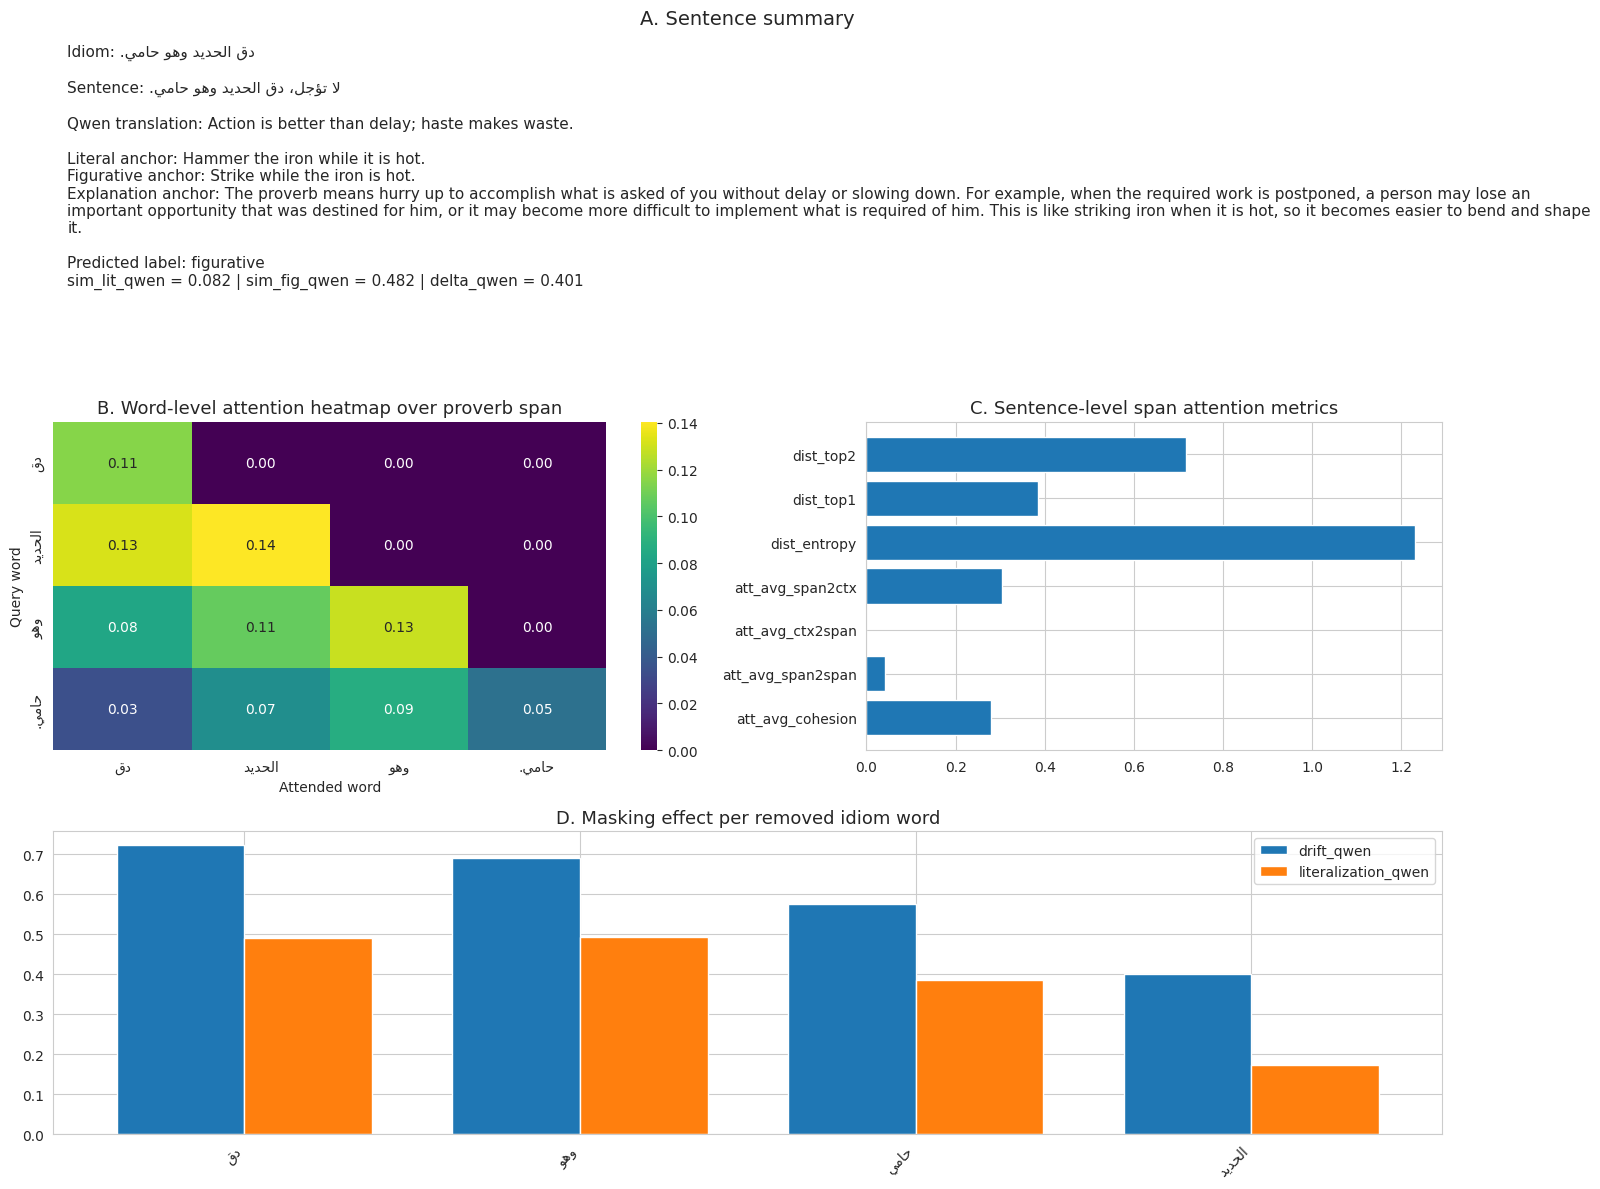


Top masking rows for this sentence:


,idiom_word_removed_clean,idiom_word_removed,masked_sentence,masked_qwen,drift_qwen,literalization_qwen
864,دق,دق,لا تؤجل، الحديد وهو حامي.,"Don't delay, iron is a guardian.",0.722709,0.491331
866,وهو,وهو,لا تؤجل، دق الحديد حامي.,"Don't delay, hammer fasten the nail.",0.691689,0.493397
867,حامي,حامي.,لا تؤجل، دق الحديد وهو,"Don't delay, hammer it down now.",0.576350,0.385822
865,الحديد,الحديد,لا تؤجل، دق وهو حامي.,"Don't delay, act now.",0.400610,0.174137


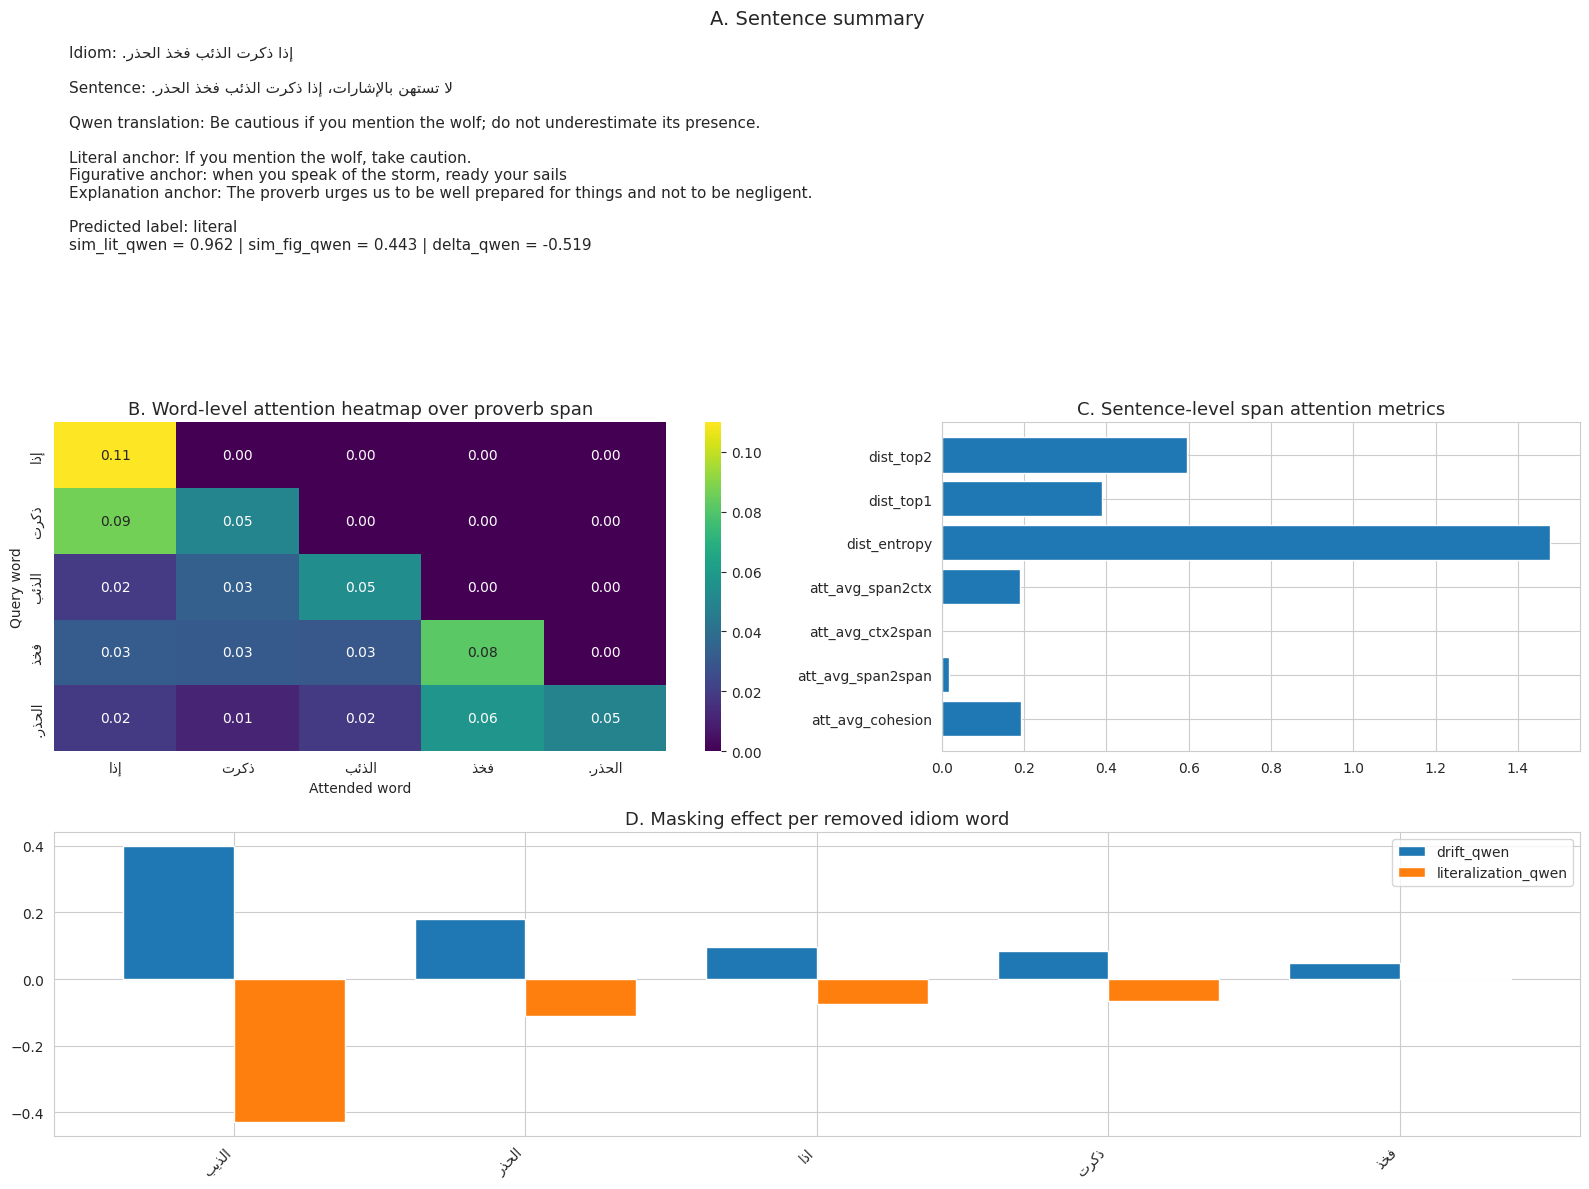


Top masking rows for this sentence:


,idiom_word_removed_clean,idiom_word_removed,masked_sentence,masked_qwen,drift_qwen,literalization_qwen
192,الذيب,الذئب,لا تستهِن بالإشارات، إذا ذكرت فخذ الحذر.,Don't overthink it; take precautions if you me...,0.398788,-0.427925
194,الحذر,الحذر.,لا تستهِن بالإشارات، إذا ذكرت الذئب فخذ,Don't be misled by the signs; if you mention t...,0.178935,-0.110435
190,اذا,إذا,لا تستهِن بالإشارات، ذكرت الذئب فخذ الحذر.,Don't underestimate signals; be wary of the wolf.,0.095022,-0.075144
191,ذكرت,ذكرت,لا تستهِن بالإشارات، إذا الذئب فخذ الحذر.,Don't underestimate signals; be cautious if th...,0.084340,-0.064533
193,فخذ,فخذ,لا تستهِن بالإشارات، إذا ذكرت الذئب الحذر.,Don't underestimate the signals; be cautious i...,0.049606,0.002823


In [14]:
### Plot Case studies
plot_case_study(row_id=fig_row_id)
plot_case_study(row_id=lit_row_id)

if collapse_row_id not in [fig_row_id, lit_row_id]:
    plot_case_study(row_id=collapse_row_id)


## Comparison Plots to add to the report

In [15]:

if "robust_df" in globals():
    final_df = robust_df.copy()
elif "features_merged" in globals():
    final_df = features_merged.copy()
elif "analysis_df" in globals():
    final_df = analysis_df.copy()
else:
    raise RuntimeError("No suitable dataframe found. Run the earlier cells first.")

rename_map = {
    "att_avg_span2span": "att_span2span",
    "att_avg_span2span_norm": "att_span2span_norm",
    "att_focus_ratio": "span_focus_ratio",
    "dist_entropy": "span_attention_entropy",
    "dist_top1": "span_top1_mass",
    "dist_top2": "span_top2_mass",
    "dist_hhi": "span_hhi",
    "maskrow_qwen_literal_collapse_rate": "literal_collapse_rate_qwen",
}

for old, new in rename_map.items():
    if old in final_df.columns and new not in final_df.columns:
        final_df = final_df.rename(columns={old: new})

# unify label column
if "label_fig" not in final_df.columns:
    if "translation_type" in final_df.columns:
        final_df["label_fig"] = final_df["translation_type"].map({"figurative":"Figurative","literal":"Literal"}).fillna(final_df["translation_type"])
    elif "delta_qwen" in final_df.columns:
        final_df["label_fig"] = np.where(final_df["delta_qwen"] > 0, "Figurative", "Literal")
    else:
        raise RuntimeError("Could not infer Figurative/Literal labels.")

# keep only valid rows
if "status" in final_df.columns:
    final_df = final_df[final_df["status"] == "ok"].copy()

ROBUST_METRICS = [
    "att_span2span",
    "att_span2span_norm",
    "span_focus_ratio",
    "span_attention_entropy",
    "span_top1_mass",
    "span_top2_mass",
    "span_hhi",
    "literal_collapse_rate_qwen",
]
ROBUST_METRICS = [m for m in ROBUST_METRICS if m in final_df.columns]

print("Rows used:", len(final_df))
print("Robust metrics:", ROBUST_METRICS)
display(final_df[[c for c in ["row_id","idiom","label_fig"] + ROBUST_METRICS if c in final_df.columns]].head())

Rows used: 250
Robust metrics: ['att_span2span', 'span_attention_entropy', 'span_top1_mass', 'span_top2_mass', 'literal_collapse_rate_qwen']


,row_id,idiom,label_fig,att_span2span,span_attention_entropy,span_top1_mass,span_top2_mass,literal_collapse_rate_qwen
0,0,آخر الحياة الموت,Literal,0.039756,0.946176,0.496355,0.898526,1.000000
1,1,آخر الحياة الموت,Literal,0.036426,0.944863,0.477636,0.901623,0.666667
2,2,أتبع من الظل.,Figurative,0.044503,0.935451,0.554941,0.890466,1.000000
3,3,أتبع من الظل.,Figurative,0.029687,0.992276,0.477335,0.863494,1.000000
4,4,أتبع من الظل.,Figurative,0.036250,1.008550,0.454552,0.851310,0.666667


In [16]:
# FIGURATIVE VS LITERAL TABLE

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests


def cohens_d_simple(a, b):
    a = pd.Series(a).dropna().astype(float)
    b = pd.Series(b).dropna().astype(float)
    if len(a) < 2 or len(b) < 2:
        return np.nan
    pooled = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
    if pooled == 0:
        return np.nan
    return (a.mean() - b.mean()) / pooled

rows = []
for metric in ROBUST_METRICS:
    fig = final_df.loc[final_df["label_fig"] == "Figurative", metric].dropna()
    lit = final_df.loc[final_df["label_fig"] == "Literal", metric].dropna()
    if len(fig) < 2 or len(lit) < 2:
        continue
    stat, p = mannwhitneyu(fig, lit, alternative="two-sided")
    rows.append({
        "metric": metric,
        "figurative_mean": fig.mean(),
        "literal_mean": lit.mean(),
        "diff_fig_minus_lit": fig.mean() - lit.mean(),
        "cohens_d": cohens_d_simple(fig, lit),
        "p_value": p,
        "n_fig": len(fig),
        "n_lit": len(lit),
    })

final_stats_df = pd.DataFrame(rows)
if len(final_stats_df):
    reject, p_adj, _, _ = multipletests(final_stats_df["p_value"], method="fdr_bh")
    final_stats_df["p_value_fdr_bh"] = p_adj
    final_stats_df["significant_fdr_0_05"] = reject
    final_stats_df = final_stats_df.sort_values(["significant_fdr_0_05","p_value_fdr_bh","cohens_d"], ascending=[False,True,False])

display(final_stats_df)

#good res
DEFENDABLE_RESULTS_DF = final_stats_df[(final_stats_df["significant_fdr_0_05"]) & (final_stats_df["cohens_d"].abs() >= 0.30)].copy()
print("Defendable results only:")
display(DEFENDABLE_RESULTS_DF)

,metric,figurative_mean,literal_mean,diff_fig_minus_lit,cohens_d,p_value,n_fig,n_lit,p_value_fdr_bh,significant_fdr_0_05
4,literal_collapse_rate_qwen,0.860370,0.647537,0.212833,0.758841,6.962358e-08,90,160,3.481179e-07,True
0,att_span2span,0.026343,0.022572,0.003771,0.419152,5.130084e-05,90,160,1.282521e-04,True
1,span_attention_entropy,1.172239,1.258765,-0.086526,-0.228627,6.426400e-02,90,160,1.071067e-01,False
2,span_top1_mass,0.459017,0.432543,0.026473,0.183480,2.170265e-01,90,160,2.170265e-01,False
3,span_top2_mass,0.745054,0.713569,0.031485,0.180768,2.038385e-01,90,160,2.170265e-01,False


Defendable results only:


,metric,figurative_mean,literal_mean,diff_fig_minus_lit,cohens_d,p_value,n_fig,n_lit,p_value_fdr_bh,significant_fdr_0_05
4,literal_collapse_rate_qwen,0.860370,0.647537,0.212833,0.758841,6.962358e-08,90,160,3.481179e-07,True
0,att_span2span,0.026343,0.022572,0.003771,0.419152,5.130084e-05,90,160,1.282521e-04,True


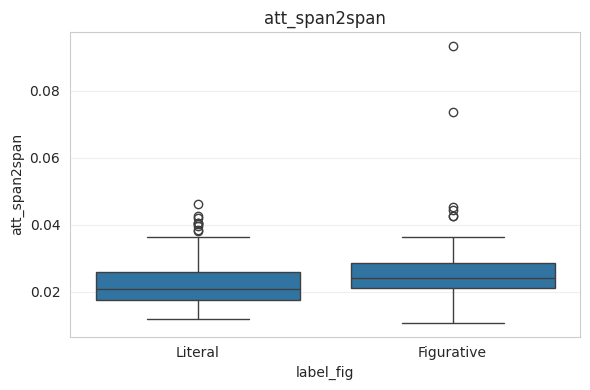

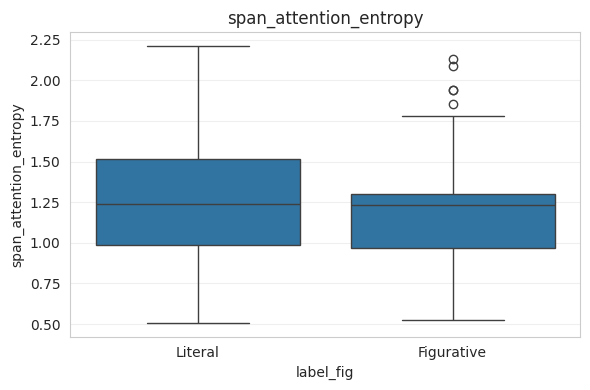

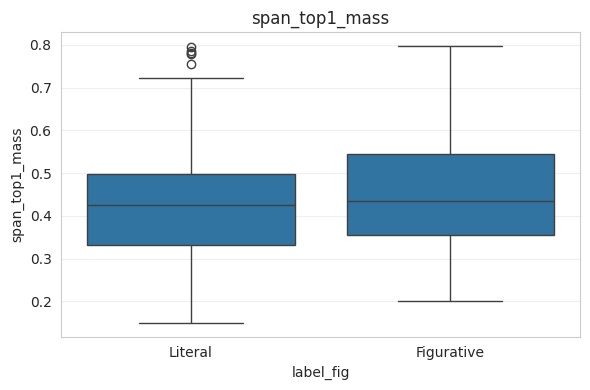

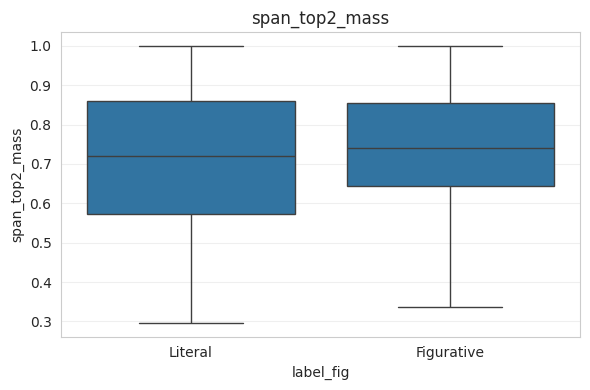

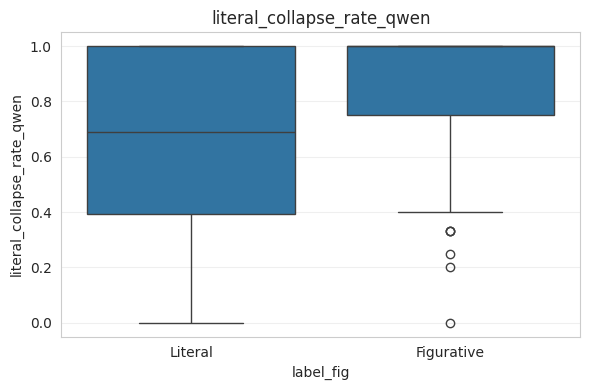

In [17]:
#PLOTS

PLOT_METRICS = [m for m in [
    "att_span2span",
    "att_span2span_norm",
    "span_focus_ratio",
    "span_attention_entropy",
    "span_top1_mass",
    "span_top2_mass",
    "literal_collapse_rate_qwen",
] if m in final_df.columns]

for metric in PLOT_METRICS:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=final_df, x="label_fig", y=metric)
    plt.title(metric)
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

small explanation for the literal collapse plot: figurative idioms are so likelt to undergo literal collapse => the model is more likely to drift toward literal representation
=> the model gives figurative idioms slightly more internal attention structure but it still collpses into literal meaning more ofter => figurative idioms remain much more semantically fragile

In [19]:
if "DEFENDABLE_RESULTS_DF" in globals() and len(DEFENDABLE_RESULTS_DF):
    keep = DEFENDABLE_RESULTS_DF[["metric","figurative_mean","literal_mean","cohens_d","p_value_fdr_bh"]].copy()
    display(keep)

,metric,figurative_mean,literal_mean,cohens_d,p_value_fdr_bh
4,literal_collapse_rate_qwen,0.860370,0.647537,0.758841,3.481179e-07
0,att_span2span,0.026343,0.022572,0.419152,1.282521e-04
